In [1]:
!rm -rf STGAT

In [2]:
!git clone https://github.com/xyk0058/STGAT.git
%cd STGAT

Cloning into 'STGAT'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 70 (delta 15), reused 66 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (70/70), 35.32 MiB | 17.23 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Updating files: 100% (53/53), done.
/content/STGAT


In [3]:
!pip install numpy pandas scipy scikit-learn torch

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!ls /content/drive/MyDrive/Datasets

adj_mx.pkl  metr-la.h5


In [6]:
!ls /content/drive/MyDrive/STGAT_data/METR-LA/

ls: cannot access '/content/drive/MyDrive/STGAT_data/METR-LA/': No such file or directory


In [7]:
!mkdir -p data/METR-LA

!cp /content/drive/MyDrive/Datasets/metr-la.h5 data/METR-LA/
!cp /content/drive/MyDrive/Datasets/adj_mx.pkl data/METR-LA/

In [8]:
!ls data/METR-LA

adj_mx.pkl  metr-la.h5


In [9]:
!python train.py \
--data data/METR-LA/metr-la.h5 \
--adj_filename data/METR-LA/adj_mx.pkl \
--num_of_vertices 207 \
--num_of_features 1 \
--points_per_hour 12 \
--num_for_predict 12 \
--batch_size 64 \
--epoch 10 \
--lr 0.001

Training configs: Namespace(data='data/METR-LA/metr-la.h5', adj_filename='data/METR-LA/adj_mx.pkl', params_dir='experiment_METR_LA', num_of_vertices=207, num_of_features=1, points_per_hour=12, num_for_predict=12, num_of_weeks=1, num_of_days=1, num_of_hours=1, batch_size=64, epoch=10, lr=0.001, print_every=200, opt='adam', graph='default', adjtype='symnadj', early_stop_maxtry=20, cuda=False)
Traceback (most recent call last):
  File "/content/STGAT/train.py", line 293, in <module>
    main()
  File "/content/STGAT/train.py", line 62, in main
    dataloader = util.load_dataset(args.data, args.batch_size, args.batch_size, args.batch_size)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/STGAT/util.py", line 152, in load_dataset
    cat_data = np.load(os.path.join(dataset_dir, category + '.npz'))
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npy

In [10]:
!mkdir -p data/METR-LA

In [11]:
import numpy as np
import pandas as pd

df = pd.read_hdf("data/METR-LA/metr-la.h5")
data = df.values  # (time, nodes)

# normalize
mean = data.mean()
std = data.std()
data = (data - mean) / std

# create sequences
def create_dataset(data, input_len=12, output_len=12):
    X, Y = [], []
    for i in range(len(data) - input_len - output_len):
        X.append(data[i:i+input_len])
        Y.append(data[i+input_len:i+input_len+output_len])
    return np.array(X), np.array(Y)

X, Y = create_dataset(data)

# ✅ ADD FEATURE DIMENSION HERE
X = X[..., np.newaxis]
Y = Y[..., np.newaxis]

# split
train_size = int(0.7 * len(X))
val_size = int(0.1 * len(X))

X_train, Y_train = X[:train_size], Y[:train_size]
X_val, Y_val = X[train_size:train_size+val_size], Y[train_size:train_size+val_size]
X_test, Y_test = X[train_size+val_size:], Y[train_size+val_size:]

# save
np.savez("data/METR-LA/train.npz", x=X_train, y=Y_train)
np.savez("data/METR-LA/val.npz", x=X_val, y=Y_val)
np.savez("data/METR-LA/test.npz", x=X_test, y=Y_test)

print("Fixed dataset created!")

data = np.load("data/METR-LA/train.npz")
print(data['x'].shape)

Fixed dataset created!
(23973, 12, 207, 1)


In [12]:
!ls data/METR-LA

adj_mx.pkl  metr-la.h5	test.npz  train.npz  val.npz


In [13]:
!python train.py \
--data data/METR-LA \
--adj_filename data/METR-LA/adj_mx.pkl \
--num_of_vertices 207 \
--num_of_features 1 \
--points_per_hour 12 \
--num_for_predict 12 \
--batch_size 64 \
--epoch 10 \
--lr 0.001

Training configs: Namespace(data='data/METR-LA', adj_filename='data/METR-LA/adj_mx.pkl', params_dir='experiment_METR_LA', num_of_vertices=207, num_of_features=1, points_per_hour=12, num_for_predict=12, num_of_weeks=1, num_of_days=1, num_of_hours=1, batch_size=64, epoch=10, lr=0.001, print_every=200, opt='adam', graph='default', adjtype='symnadj', early_stop_maxtry=20, cuda=False)
adj torch.Size([207, 207])
Namespace(data='data/METR-LA', adj_filename='data/METR-LA/adj_mx.pkl', params_dir='experiment_METR_LA', num_of_vertices=207, num_of_features=1, points_per_hour=12, num_for_predict=12, num_of_weeks=1, num_of_days=1, num_of_hours=1, batch_size=64, epoch=10, lr=0.001, print_every=200, opt='adam', graph='default', adjtype='symnadj', early_stop_maxtry=20, cuda=False)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, 

In [14]:
!python test.py \
--data data/METR-LA \
--adj_filename data/METR-LA/adj_mx.pkl

Training configs: Namespace(data='data/METR-LA', adj_filename='data/METR-LA/adj_mx.pkl', params_dir='experiment_METR_LA', num_of_vertices=207, num_of_features=2, points_per_hour=12, num_for_predict=12, num_of_weeks=1, num_of_days=1, num_of_hours=1, batch_size=64, epoch=1000, lr=0.001, print_every=100, opt='adam', graph='default', adjtype='symnadj', early_stop_maxtry=1000, cuda=False)
tensor([[-0.2734,  0.5886,  0.9499],
        [-0.2129, -1.2150,  0.3526],
        [-0.6973,  0.1729, -0.5595]])
tensor([[0.1612, 0.7471, 1.9457],
        [0.0978, 3.1836, 0.2681],
        [1.0487, 0.0645, 0.6751]])


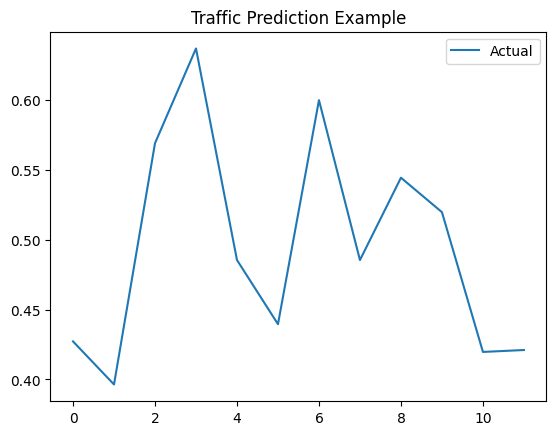

In [15]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("data/METR-LA/test.npz")

x = data['x']
y = data['y']

# pick one sample
sample_x = x[0]
sample_y = y[0]

plt.plot(sample_y[:, 0, 0], label="Actual")
plt.title("Traffic Prediction Example")
plt.legend()
plt.show()